# DetectiveQA: TF-IDF và BM25 retrieval baselines

In [1]:
REPO_URL = "https://github.com/TranTheHung2312332/canon-layer.git" #@param {type:"string"}
BRANCH = "main"
REPO_DIR = "/content/repo"

MAX_QUERIES = 0

TOP_K = 10
RUN_DEPTH = 100
RANDOM_SEED = 42

In [2]:
!pip install -q rank-bm25 scikit-learn pandas numpy tqdm matplotlib

In [3]:
#@title 3. Clone repo

from pathlib import Path
import os
import subprocess

repo_dir = Path(REPO_DIR)

if "<YOUR_USERNAME>" in REPO_URL or not REPO_URL.startswith(("https://", "git@")):
    raise ValueError(
        "Hãy thay REPO_URL bằng URL GitHub thật của repository lore-router."
    )

if (repo_dir / ".git").exists():
    print(f"Repository đã tồn tại tại {repo_dir}. Đang cập nhật branch {BRANCH}...")
    subprocess.run(["git", "-C", str(repo_dir), "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", str(repo_dir), "checkout", BRANCH], check=True)
    subprocess.run(
        ["git", "-C", str(repo_dir), "pull", "--ff-only", "origin", BRANCH],
        check=True,
    )
else:
    repo_dir.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        [
            "git", "clone",
            "--depth", "1",
            "--branch", BRANCH,
            REPO_URL,
            str(repo_dir),
        ],
        check=True,
    )

os.chdir(repo_dir)
print("Working directory:", Path.cwd())

Working directory: /content/repo


## 4. Kiểm tra dữ liệu

In [4]:
from pathlib import Path

DATA_DIR = Path("data/detectiveqa-ranking-en")
CORPUS_PATH = DATA_DIR / "corpus.jsonl"
QUERIES_PATH = DATA_DIR / "queries.jsonl"
QUERY_METADATA_PATH = DATA_DIR / "query_metadata.jsonl"
QRELS_PATH = DATA_DIR / "qrels" / "test.tsv"

required_paths = [CORPUS_PATH, QUERIES_PATH, QUERY_METADATA_PATH, QRELS_PATH]
missing = [str(path) for path in required_paths if not path.exists()]

if missing:
    raise FileNotFoundError(
        "Thiếu các file dữ liệu sau:\n- " + "\n- ".join(missing)
        + "\nHãy chạy prepare_detectiveqa_ranking.py trước."
    )

print("Đã tìm thấy đầy đủ dữ liệu:")
for path in required_paths:
    print(" -", path)

Đã tìm thấy đầy đủ dữ liệu:
 - data/detectiveqa-ranking-en/corpus.jsonl
 - data/detectiveqa-ranking-en/queries.jsonl
 - data/detectiveqa-ranking-en/query_metadata.jsonl
 - data/detectiveqa-ranking-en/qrels/test.tsv


## 5. Load corpus, queries, metadata và qrels

In [5]:
import json
import re
from collections import defaultdict
from typing import Any

import numpy as np
import pandas as pd


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    records = []
    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(f"JSON không hợp lệ tại {path}:{line_number}") from exc
    return records


corpus_records = read_jsonl(CORPUS_PATH)
query_records = read_jsonl(QUERIES_PATH)
metadata_records = read_jsonl(QUERY_METADATA_PATH)

corpus = {record["_id"]: record for record in corpus_records}
queries = {record["_id"]: record["text"] for record in query_records}
query_metadata = {
    record.get("query_id", record.get("_id")): record
    for record in metadata_records
}

qrels_df = pd.read_csv(QRELS_PATH, sep="\t")
expected_columns = {"query-id", "corpus-id", "score"}
if not expected_columns.issubset(qrels_df.columns):
    raise ValueError(
        f"qrels phải có các cột {sorted(expected_columns)}; "
        f"hiện có {qrels_df.columns.tolist()}"
    )

qrels_df = qrels_df[qrels_df["score"] > 0].copy()
qrels_df = qrels_df.drop_duplicates(subset=["query-id", "corpus-id"])

gold_by_query = defaultdict(set)
for _, row in qrels_df.iterrows():
    gold_by_query[str(row["query-id"])].add(str(row["corpus-id"]))


DOC_ID_PATTERN = re.compile(r"^dqa-en-(\d+)-p\d+$")
QUERY_ID_PATTERN = re.compile(
    r"^dqa-en-(?:human_anno|AIsup_anno)-(\d+)-q\d+$"
)


def novel_id_from_doc_id(doc_id: str) -> int:
    match = DOC_ID_PATTERN.match(doc_id)
    if not match:
        raise ValueError(f"Không đọc được novel_id từ document ID: {doc_id}")
    return int(match.group(1))


def novel_id_from_query(query_id: str) -> int:
    metadata = query_metadata.get(query_id)
    if metadata is not None and metadata.get("novel_id") is not None:
        return int(metadata["novel_id"])

    match = QUERY_ID_PATTERN.match(query_id)
    if not match:
        raise ValueError(f"Không đọc được novel_id từ query ID: {query_id}")
    return int(match.group(1))


if not corpus:
    raise ValueError("Corpus rỗng.")
if not queries:
    raise ValueError("Query set rỗng.")

non_english_docs = [doc_id for doc_id in corpus if not doc_id.startswith("dqa-en-")]
non_english_queries = [qid for qid in queries if not qid.startswith("dqa-en-")]
if non_english_docs or non_english_queries:
    raise ValueError(
        "Phát hiện ID không thuộc English release. "
        f"docs={non_english_docs[:3]}, queries={non_english_queries[:3]}"
    )

missing_gold_docs = sorted(
    {
        doc_id
        for gold_docs in gold_by_query.values()
        for doc_id in gold_docs
        if doc_id not in corpus
    }
)
if missing_gold_docs:
    raise ValueError(
        f"Có {len(missing_gold_docs)} gold document không tồn tại trong corpus. "
        f"Ví dụ: {missing_gold_docs[:5]}"
    )

evaluation_query_ids = sorted(
    qid for qid in queries
    if qid in gold_by_query and len(gold_by_query[qid]) > 0
)

if MAX_QUERIES and MAX_QUERIES > 0:
    rng = np.random.default_rng(RANDOM_SEED)
    sample_size = min(MAX_QUERIES, len(evaluation_query_ids))
    evaluation_query_ids = sorted(
        rng.choice(evaluation_query_ids, size=sample_size, replace=False).tolist()
    )

print(f"Corpus documents:       {len(corpus):,}")
print(f"All queries:            {len(queries):,}")
print(f"Queries with positives: {len(gold_by_query):,}")
print(f"Queries evaluated:      {len(evaluation_query_ids):,}")
print(f"Positive qrels:         {len(qrels_df):,}")

Corpus documents:       65,641
All queries:            149
Queries with positives: 149
Queries evaluated:      149
Positive qrels:         848


## 6. Nhóm document và query theo novel


In [6]:
docs_by_novel = defaultdict(list)
for doc_id in corpus:
    docs_by_novel[novel_id_from_doc_id(doc_id)].append(doc_id)


def paragraph_index(doc_id: str) -> int:
    return int(doc_id.rsplit("-p", maxsplit=1)[1])


for novel_id in docs_by_novel:
    docs_by_novel[novel_id].sort(key=paragraph_index)

queries_by_novel = defaultdict(list)
for query_id in evaluation_query_ids:
    queries_by_novel[novel_id_from_query(query_id)].append(query_id)

novel_stats = pd.DataFrame(
    [
        {
            "novel_id": novel_id,
            "documents": len(doc_ids),
            "queries": len(queries_by_novel.get(novel_id, [])),
        }
        for novel_id, doc_ids in sorted(docs_by_novel.items())
    ]
)

display(novel_stats[novel_stats["queries"] > 0].reset_index(drop=True))

,novel_id,documents,queries
0,27,2938,7
1,79,4315,5
2,117,2097,5
3,118,2884,7
4,121,2586,6
5,124,3276,6
6,126,2339,6
7,128,2218,6
8,134,2958,6
9,136,2819,6


## 7. Tokenization và metric

In [7]:
import math
from collections.abc import Sequence

TOKEN_PATTERN = re.compile(r"(?u)\b\w\w+\b")


def tokenize(text: str) -> list[str]:
    return TOKEN_PATTERN.findall(text.lower())


def precision_at_k(ranked_doc_ids, gold_doc_ids, k):
    top_k = ranked_doc_ids[:k]
    hits = sum(doc_id in gold_doc_ids for doc_id in top_k)
    return hits / k


def recall_at_k(ranked_doc_ids, gold_doc_ids, k):
    if not gold_doc_ids:
        return 0.0
    top_k = ranked_doc_ids[:k]
    hits = sum(doc_id in gold_doc_ids for doc_id in top_k)
    return hits / len(gold_doc_ids)


def reciprocal_rank(ranked_doc_ids, gold_doc_ids):
    for rank, doc_id in enumerate(ranked_doc_ids, start=1):
        if doc_id in gold_doc_ids:
            return 1.0 / rank
    return 0.0


def ndcg_at_k(ranked_doc_ids, gold_doc_ids, k):
    if not gold_doc_ids:
        return 0.0

    dcg = 0.0
    for rank, doc_id in enumerate(ranked_doc_ids[:k], start=1):
        relevance = 1.0 if doc_id in gold_doc_ids else 0.0
        dcg += relevance / math.log2(rank + 1)

    ideal_hits = min(len(gold_doc_ids), k)
    idcg = sum(
        1.0 / math.log2(rank + 1)
        for rank in range(1, ideal_hits + 1)
    )
    return dcg / idcg if idcg > 0 else 0.0


def evaluate_ranking(ranked_doc_ids, gold_doc_ids, k=10):
    return {
        f"precision@{k}": precision_at_k(ranked_doc_ids, gold_doc_ids, k),
        f"recall@{k}": recall_at_k(ranked_doc_ids, gold_doc_ids, k),
        "mrr": reciprocal_rank(ranked_doc_ids, gold_doc_ids),
        f"ndcg@{k}": ndcg_at_k(ranked_doc_ids, gold_doc_ids, k),
    }


# Sanity checks
_test_ranking = ["d1", "d2", "d3", "d4"]
_test_gold = {"d2", "d4"}
assert precision_at_k(_test_ranking, _test_gold, 2) == 0.5
assert recall_at_k(_test_ranking, _test_gold, 2) == 0.5
assert reciprocal_rank(_test_ranking, _test_gold) == 0.5
assert 0.0 <= ndcg_at_k(_test_ranking, _test_gold, 4) <= 1.0

print("Metric sanity checks passed.")

Metric sanity checks passed.


## 8. Chạy TF-IDF và BM25

In [8]:
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.auto import tqdm


def stable_descending_rank(scores: np.ndarray) -> np.ndarray:
    return np.argsort(-scores, kind="mergesort")


metric_rows = []
run_rows = {"tfidf": [], "bm25": []}

for novel_id in tqdm(sorted(queries_by_novel), desc="Novels"):
    doc_ids = docs_by_novel.get(novel_id, [])
    query_ids = queries_by_novel[novel_id]

    if not doc_ids:
        raise ValueError(f"Novel {novel_id} không có candidate documents.")

    document_texts = [corpus[doc_id]["text"] for doc_id in doc_ids]

    # TF-IDF index cho novel
    tfidf_vectorizer = TfidfVectorizer(
        lowercase=True,
        token_pattern=r"(?u)\b\w\w+\b",
        ngram_range=(1, 1),
        norm="l2",
        sublinear_tf=True,
        dtype=np.float32,
    )
    tfidf_document_matrix = tfidf_vectorizer.fit_transform(document_texts)

    # BM25 index cho novel
    tokenized_documents = [tokenize(text) for text in document_texts]
    bm25_index = BM25Okapi(tokenized_documents)

    candidate_set = set(doc_ids)

    for query_id in query_ids:
        query_text = queries[query_id]
        gold_doc_ids = gold_by_query[query_id]

        missing_from_candidate = gold_doc_ids - candidate_set
        if missing_from_candidate:
            raise ValueError(
                f"Query {query_id} có gold ngoài novel {novel_id}: "
                f"{sorted(missing_from_candidate)}"
            )

        # TF-IDF
        tfidf_query_vector = tfidf_vectorizer.transform([query_text])
        tfidf_scores = (
            tfidf_document_matrix @ tfidf_query_vector.T
        ).toarray().ravel()
        tfidf_order = stable_descending_rank(tfidf_scores)
        tfidf_ranking = [doc_ids[index] for index in tfidf_order]

        metric_rows.append(
            {
                "method": "TF-IDF",
                "query_id": query_id,
                "novel_id": novel_id,
                "num_candidates": len(doc_ids),
                "num_relevant": len(gold_doc_ids),
                **evaluate_ranking(tfidf_ranking, gold_doc_ids, TOP_K),
            }
        )

        for rank, index in enumerate(tfidf_order[:RUN_DEPTH], start=1):
            doc_id = doc_ids[index]
            run_rows["tfidf"].append(
                {
                    "query_id": query_id,
                    "doc_id": doc_id,
                    "rank": rank,
                    "score": float(tfidf_scores[index]),
                    "relevant": int(doc_id in gold_doc_ids),
                }
            )

        # BM25
        bm25_scores = np.asarray(
            bm25_index.get_scores(tokenize(query_text)),
            dtype=np.float32,
        )
        bm25_order = stable_descending_rank(bm25_scores)
        bm25_ranking = [doc_ids[index] for index in bm25_order]

        metric_rows.append(
            {
                "method": "BM25",
                "query_id": query_id,
                "novel_id": novel_id,
                "num_candidates": len(doc_ids),
                "num_relevant": len(gold_doc_ids),
                **evaluate_ranking(bm25_ranking, gold_doc_ids, TOP_K),
            }
        )

        for rank, index in enumerate(bm25_order[:RUN_DEPTH], start=1):
            doc_id = doc_ids[index]
            run_rows["bm25"].append(
                {
                    "query_id": query_id,
                    "doc_id": doc_id,
                    "rank": rank,
                    "score": float(bm25_scores[index]),
                    "relevant": int(doc_id in gold_doc_ids),
                }
            )

per_query_metrics = pd.DataFrame(metric_rows)
print("Hoàn tất:", len(per_query_metrics), "method-query rows")

Novels:   0%|          | 0/23 [00:00<?, ?it/s]

Hoàn tất: 298 method-query rows


## 9. Tổng hợp kết quả

In [9]:
metric_columns = [
    f"precision@{TOP_K}",
    f"recall@{TOP_K}",
    "mrr",
    f"ndcg@{TOP_K}",
]

summary = (
    per_query_metrics
    .groupby("method", as_index=False)[metric_columns]
    .mean()
    .sort_values(f"recall@{TOP_K}", ascending=False)
    .reset_index(drop=True)
)

summary["queries"] = per_query_metrics["query_id"].nunique()

display(
    summary.style.format(
        {
            f"precision@{TOP_K}": "{:.4f}",
            f"recall@{TOP_K}": "{:.4f}",
            "mrr": "{:.4f}",
            f"ndcg@{TOP_K}": "{:.4f}",
        }
    )
)

,method,precision@10,recall@10,mrr,ndcg@10,queries
0,BM25,0.0161,0.0320,0.0551,0.0241,149
1,TF-IDF,0.0121,0.0242,0.0433,0.0180,149


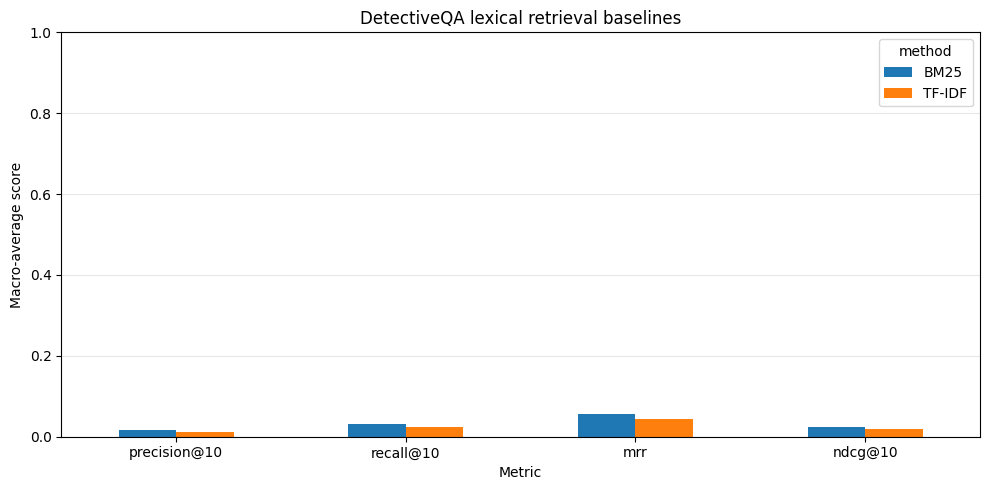

In [10]:
import matplotlib.pyplot as plt

plot_df = summary.set_index("method")[metric_columns].T
ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("DetectiveQA lexical retrieval baselines")
ax.set_xlabel("Metric")
ax.set_ylabel("Macro-average score")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Phân tích theo novel

In [11]:
per_novel_summary = (
    per_query_metrics
    .groupby(["method", "novel_id"], as_index=False)
    .agg(
        queries=("query_id", "nunique"),
        precision_at_10=(f"precision@{TOP_K}", "mean"),
        recall_at_10=(f"recall@{TOP_K}", "mean"),
        mrr=("mrr", "mean"),
        ndcg_at_10=(f"ndcg@{TOP_K}", "mean"),
    )
    .sort_values(["method", "recall_at_10"], ascending=[True, True])
)

display(per_novel_summary.reset_index(drop=True))

,method,novel_id,queries,precision_at_10,recall_at_10,mrr,ndcg_at_10
0,BM25,79,5,0.000000,0.000000,0.006431,0.000000
1,BM25,121,6,0.000000,0.000000,0.027133,0.000000
2,BM25,142,6,0.000000,0.000000,0.017418,0.000000
3,BM25,145,6,0.000000,0.000000,0.025185,0.000000
4,BM25,150,6,0.000000,0.000000,0.008514,0.000000
5,BM25,198,9,0.000000,0.000000,0.014544,0.000000
6,BM25,241,7,0.000000,0.000000,0.017523,0.000000
7,BM25,118,7,0.014286,0.014286,0.033677,0.012163
8,BM25,126,6,0.016667,0.016667,0.032418,0.011572
9,BM25,117,5,0.020000,0.018182,0.060354,0.017029


## 11. Xem một query và top kết quả

In [14]:
EXAMPLE_QUERY_ID = "dqa-en-human_anno-117-q000" #@param {type:"string"}
EXAMPLE_METHOD = "bm25" #@param ["bm25", "tfidf"]

if not EXAMPLE_QUERY_ID:
    EXAMPLE_QUERY_ID = evaluation_query_ids[0]

if EXAMPLE_QUERY_ID not in queries:
    raise KeyError(f"Không tồn tại query: {EXAMPLE_QUERY_ID}")

example_run = pd.DataFrame(run_rows[EXAMPLE_METHOD])
example_run = (
    example_run[example_run["query_id"] == EXAMPLE_QUERY_ID]
    .sort_values("rank")
    .head(TOP_K)
    .copy()
)

example_run["text"] = example_run["doc_id"].map(
    lambda doc_id: corpus[doc_id]["text"]
)
example_run["text"] = example_run["text"].str.slice(0, 350)

print("Query ID:", EXAMPLE_QUERY_ID)
print("Question:", queries[EXAMPLE_QUERY_ID])
print("Gold documents:", sorted(gold_by_query[EXAMPLE_QUERY_ID]))
display(example_run[["rank", "doc_id", "score", "relevant", "text"]])

Query ID: dqa-en-human_anno-117-q000
Question: Alyona advised Polo not to tell anyone when she left, which implies that:
Gold documents: ['dqa-en-117-p101', 'dqa-en-117-p103', 'dqa-en-117-p107', 'dqa-en-117-p226', 'dqa-en-117-p229', 'dqa-en-117-p246', 'dqa-en-117-p441', 'dqa-en-117-p478', 'dqa-en-117-p92', 'dqa-en-117-p94', 'dqa-en-117-p98']


,rank,doc_id,score,relevant,text
1200,1,dqa-en-117-p612,21.376959,0,"Poirot nodded. ""There's one more thing I must ..."
1201,2,dqa-en-117-p883,17.362196,0,"Polo said, ""Yes, because Mrs. Marshall asked m..."
1202,3,dqa-en-117-p1065,12.225908,0,"""When you left the seashore, Miss Linda had al..."
1203,4,dqa-en-117-p923,10.284429,0,"Linda said, ""Yes."" She added, ""Alyona is very ..."
1204,5,dqa-en-117-p478,10.086510,1,"She smiled at him and whispered, ""Don't tell a..."
1205,6,dqa-en-117-p313,9.949668,0,"""Alyona is not good to Linda, really. I think ..."
1206,7,dqa-en-117-p1871,9.622059,0,"Poirot's lips moved, and Inspector Cornish lea..."
1207,8,dqa-en-117-p87,8.716201,0,"Colonel Barry cleared his throat. ""Speaking of..."
1208,9,dqa-en-117-p934,8.482018,0,"Linda said confidently, ""No. He never argues w..."
1209,10,dqa-en-117-p1409,7.976523,0,"""It was exactly eleven twenty, and I looked at..."
